In [1]:
import sys
sys.path.append('..')
from scripts.prepare_data import download_data

/home/kuba/RNN-ECG-analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = download_data()

In [3]:
# Podstawowe informacje o danych
print(f"Kształt danych: {df.shape}")
print(f"\nTypy kolumn:\n{df.dtypes}")
print(f"\nPodstawowe statystyki:\n{df.describe()}")

Kształt danych: (175729, 34)

Typy kolumn:
record             object
type               object
0_pre-RR            int64
0_post-RR           int64
0_pPeak           float64
0_tPeak           float64
0_rPeak           float64
0_sPeak           float64
0_qPeak           float64
0_qrs_interval      int64
0_pq_interval       int64
0_qt_interval       int64
0_st_interval       int64
0_qrs_morph0      float64
0_qrs_morph1      float64
0_qrs_morph2      float64
0_qrs_morph3      float64
0_qrs_morph4      float64
1_pre-RR            int64
1_post-RR           int64
1_pPeak           float64
1_tPeak           float64
1_rPeak           float64
1_sPeak           float64
1_qPeak           float64
1_qrs_interval      int64
1_pq_interval       int64
1_qt_interval       int64
1_st_interval       int64
1_qrs_morph0      float64
1_qrs_morph1      float64
1_qrs_morph2      float64
1_qrs_morph3      float64
1_qrs_morph4      float64
dtype: object

Podstawowe statystyki:
            0_pre-RR      0_post-RR

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

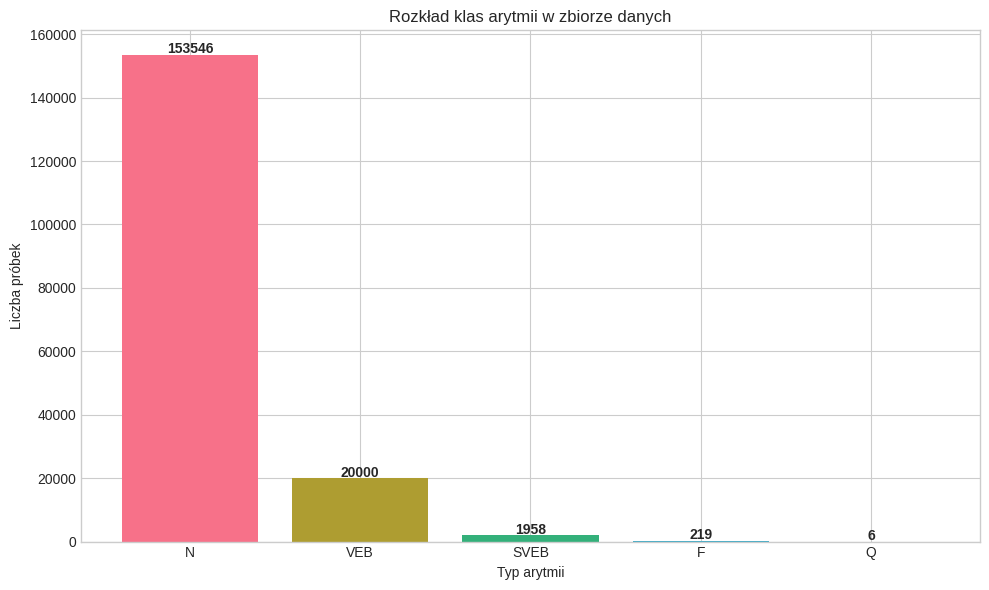

In [5]:
# Rozkład klas arytmii
fig, ax = plt.subplots(figsize=(10, 6))
class_counts = df['type'].value_counts()
ax.bar(class_counts.index, class_counts.values, color=sns.color_palette("husl", len(class_counts)))
ax.set_xlabel('Typ arytmii')
ax.set_ylabel('Liczba próbek')
ax.set_title('Rozkład klas arytmii w zbiorze danych')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

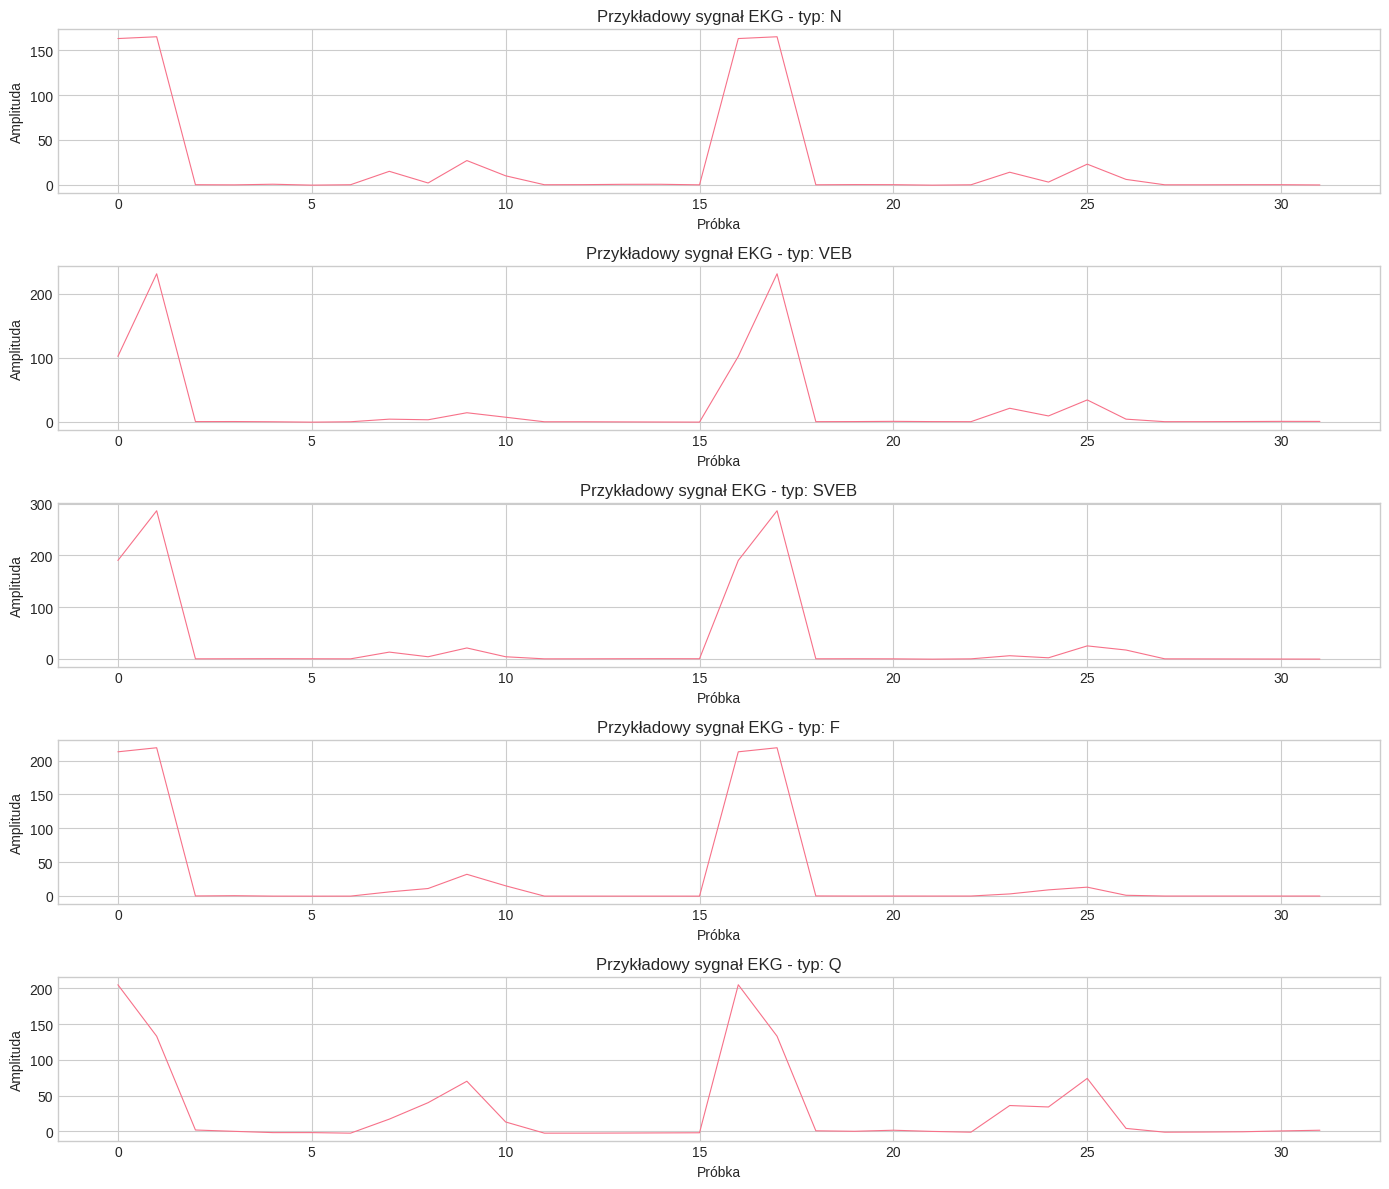

In [6]:
# Przykładowe sygnały EKG dla różnych typów arytmii
# Wybieramy kilka kolumn sygnału (bez 'record' i 'type')
signal_columns = [col for col in df.columns if col not in ['record', 'type']]

fig, axes = plt.subplots(5, 1, figsize=(14, 12))
types = df['type'].unique()

for idx, arrhythmia_type in enumerate(types):
    sample = df[df['type'] == arrhythmia_type].iloc[0]
    signal = sample[signal_columns].values
    axes[idx].plot(signal, linewidth=0.8)
    axes[idx].set_title(f'Przykładowy sygnał EKG - typ: {arrhythmia_type}')
    axes[idx].set_xlabel('Próbka')
    axes[idx].set_ylabel('Amplituda')

plt.tight_layout()
plt.show()

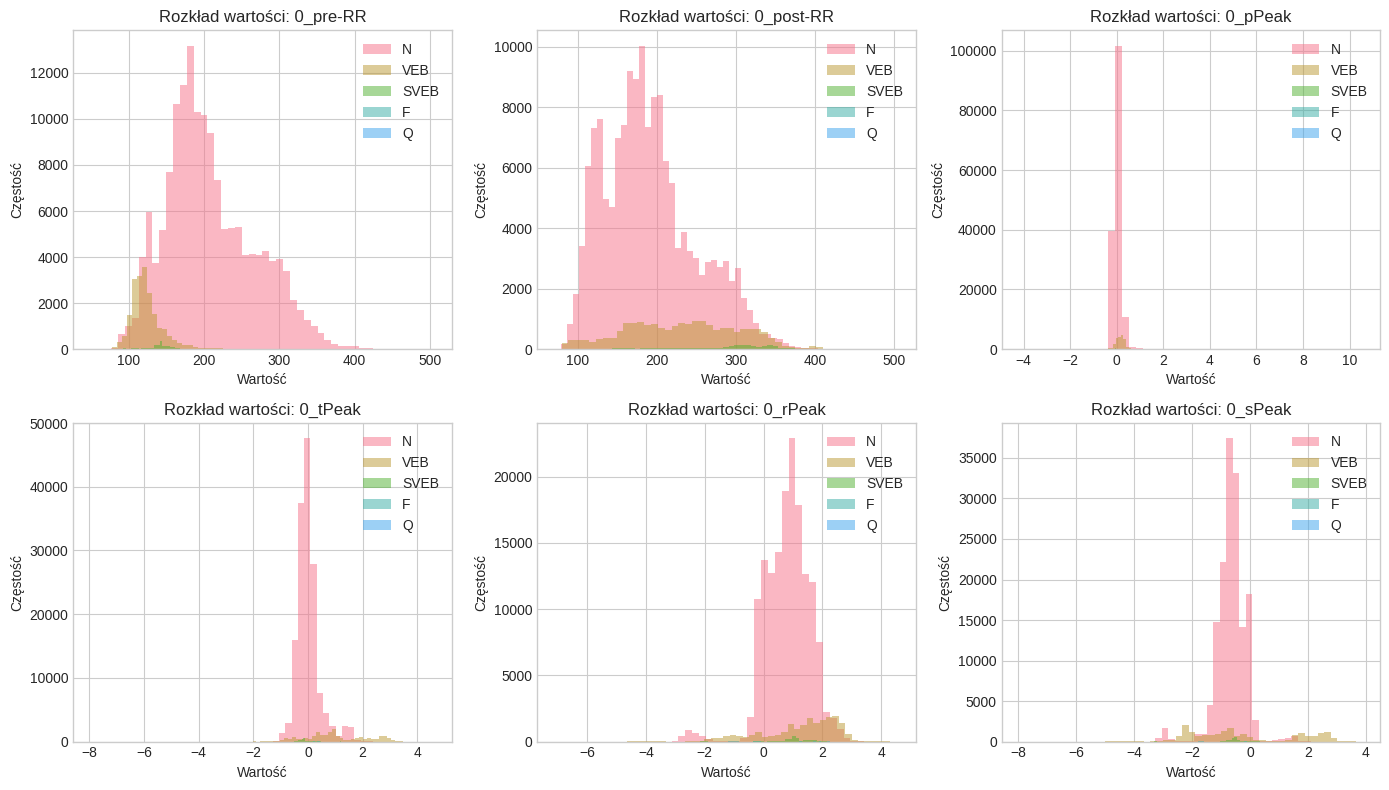

In [7]:
# Histogramy rozkładu wartości dla wybranych cech (pierwszych 6 kolumn sygnału)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(signal_columns[:6]):
    for arrhythmia_type in df['type'].unique():
        data = df[df['type'] == arrhythmia_type][col]
        axes[idx].hist(data, bins=50, alpha=0.5, label=arrhythmia_type)
    axes[idx].set_title(f'Rozkład wartości: {col}')
    axes[idx].set_xlabel('Wartość')
    axes[idx].set_ylabel('Częstość')
    axes[idx].legend()

plt.tight_layout()
plt.show()

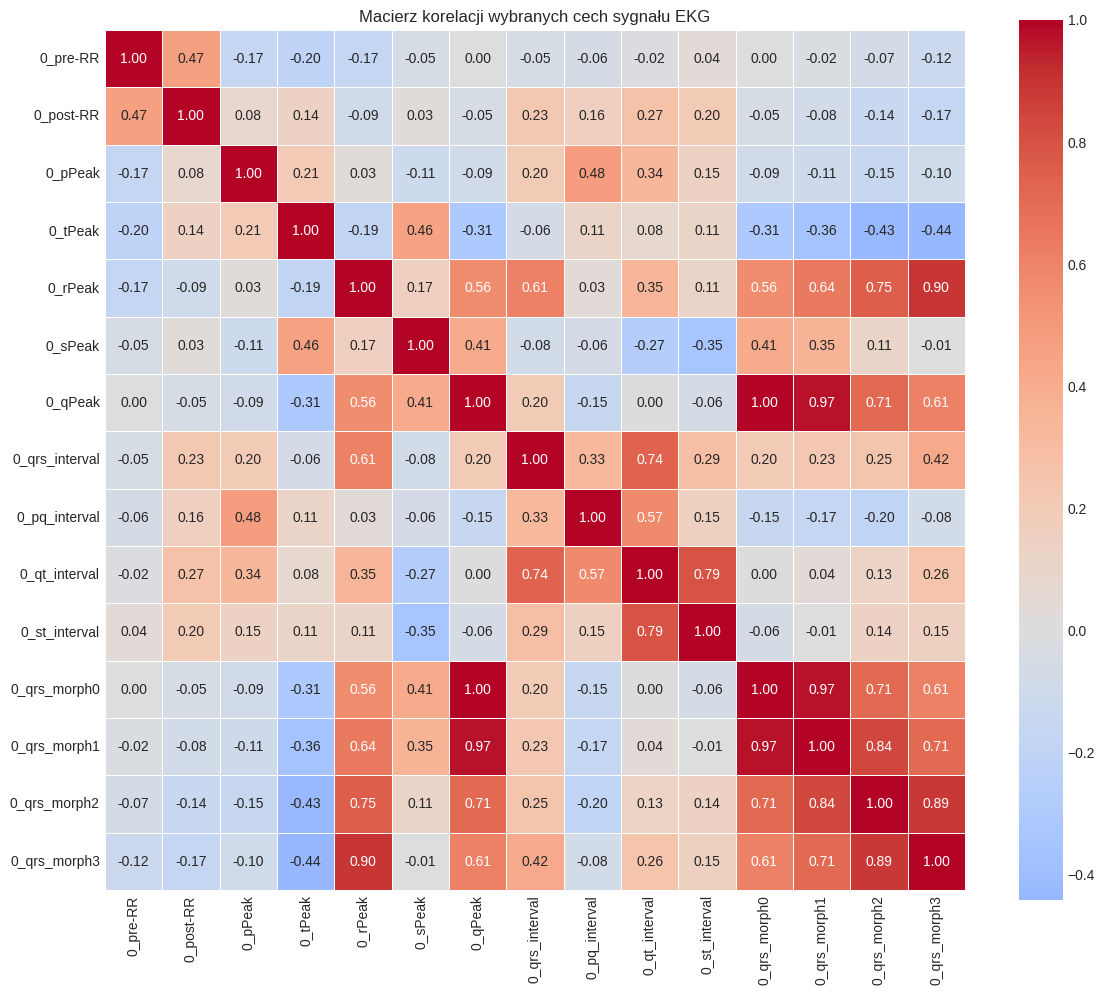

In [8]:
# Macierz korelacji dla wybranych cech
correlation_cols = signal_columns[:15]  # Pierwszych 15 kolumn
correlation_matrix = df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', ax=ax, square=True, linewidths=0.5)
ax.set_title('Macierz korelacji wybranych cech sygnału EKG')
plt.tight_layout()
plt.show()

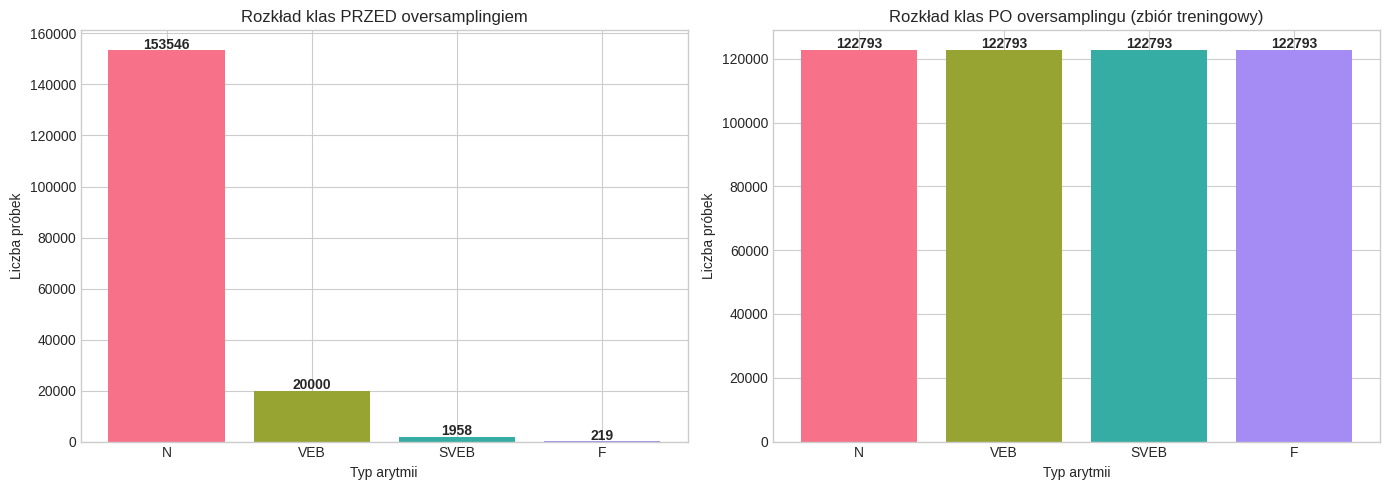


Przed oversamplingiem: 175723 próbek
Po oversamplingu (zbiór treningowy): 736758 próbek


In [9]:
# Porównanie rozkładu klas przed i po oversamplingu
from scripts.prepare_data import preproces_baseline_forest

X_train, X_test, y_train, y_test = preproces_baseline_forest(df)

# Rozkład przed oversamplingiem (oryginalne dane bez klasy Q)
df_no_q = df[df['type'] != 'Q']
original_counts = df_no_q['type'].value_counts()

# Rozkład po oversamplingu
resampled_counts = y_train.value_counts()
type_mapping = {0: 'N', 1: 'VEB', 2: 'SVEB', 3: 'F'}
resampled_counts.index = resampled_counts.index.map(type_mapping)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Przed oversamplingiem
axes[0].bar(original_counts.index, original_counts.values, color=sns.color_palette("husl", len(original_counts)))
axes[0].set_xlabel('Typ arytmii')
axes[0].set_ylabel('Liczba próbek')
axes[0].set_title('Rozkład klas PRZED oversamplingiem')
for i, v in enumerate(original_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Po oversamplingu
axes[1].bar(resampled_counts.index, resampled_counts.values, color=sns.color_palette("husl", len(resampled_counts)))
axes[1].set_xlabel('Typ arytmii')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_title('Rozkład klas PO oversamplingu (zbiór treningowy)')
for i, v in enumerate(resampled_counts.values):
    axes[1].text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nPrzed oversamplingiem: {original_counts.sum()} próbek")
print(f"Po oversamplingu (zbiór treningowy): {y_train.sum()} próbek")

Generowanie wizualizacji oryginalnych sygnałów...


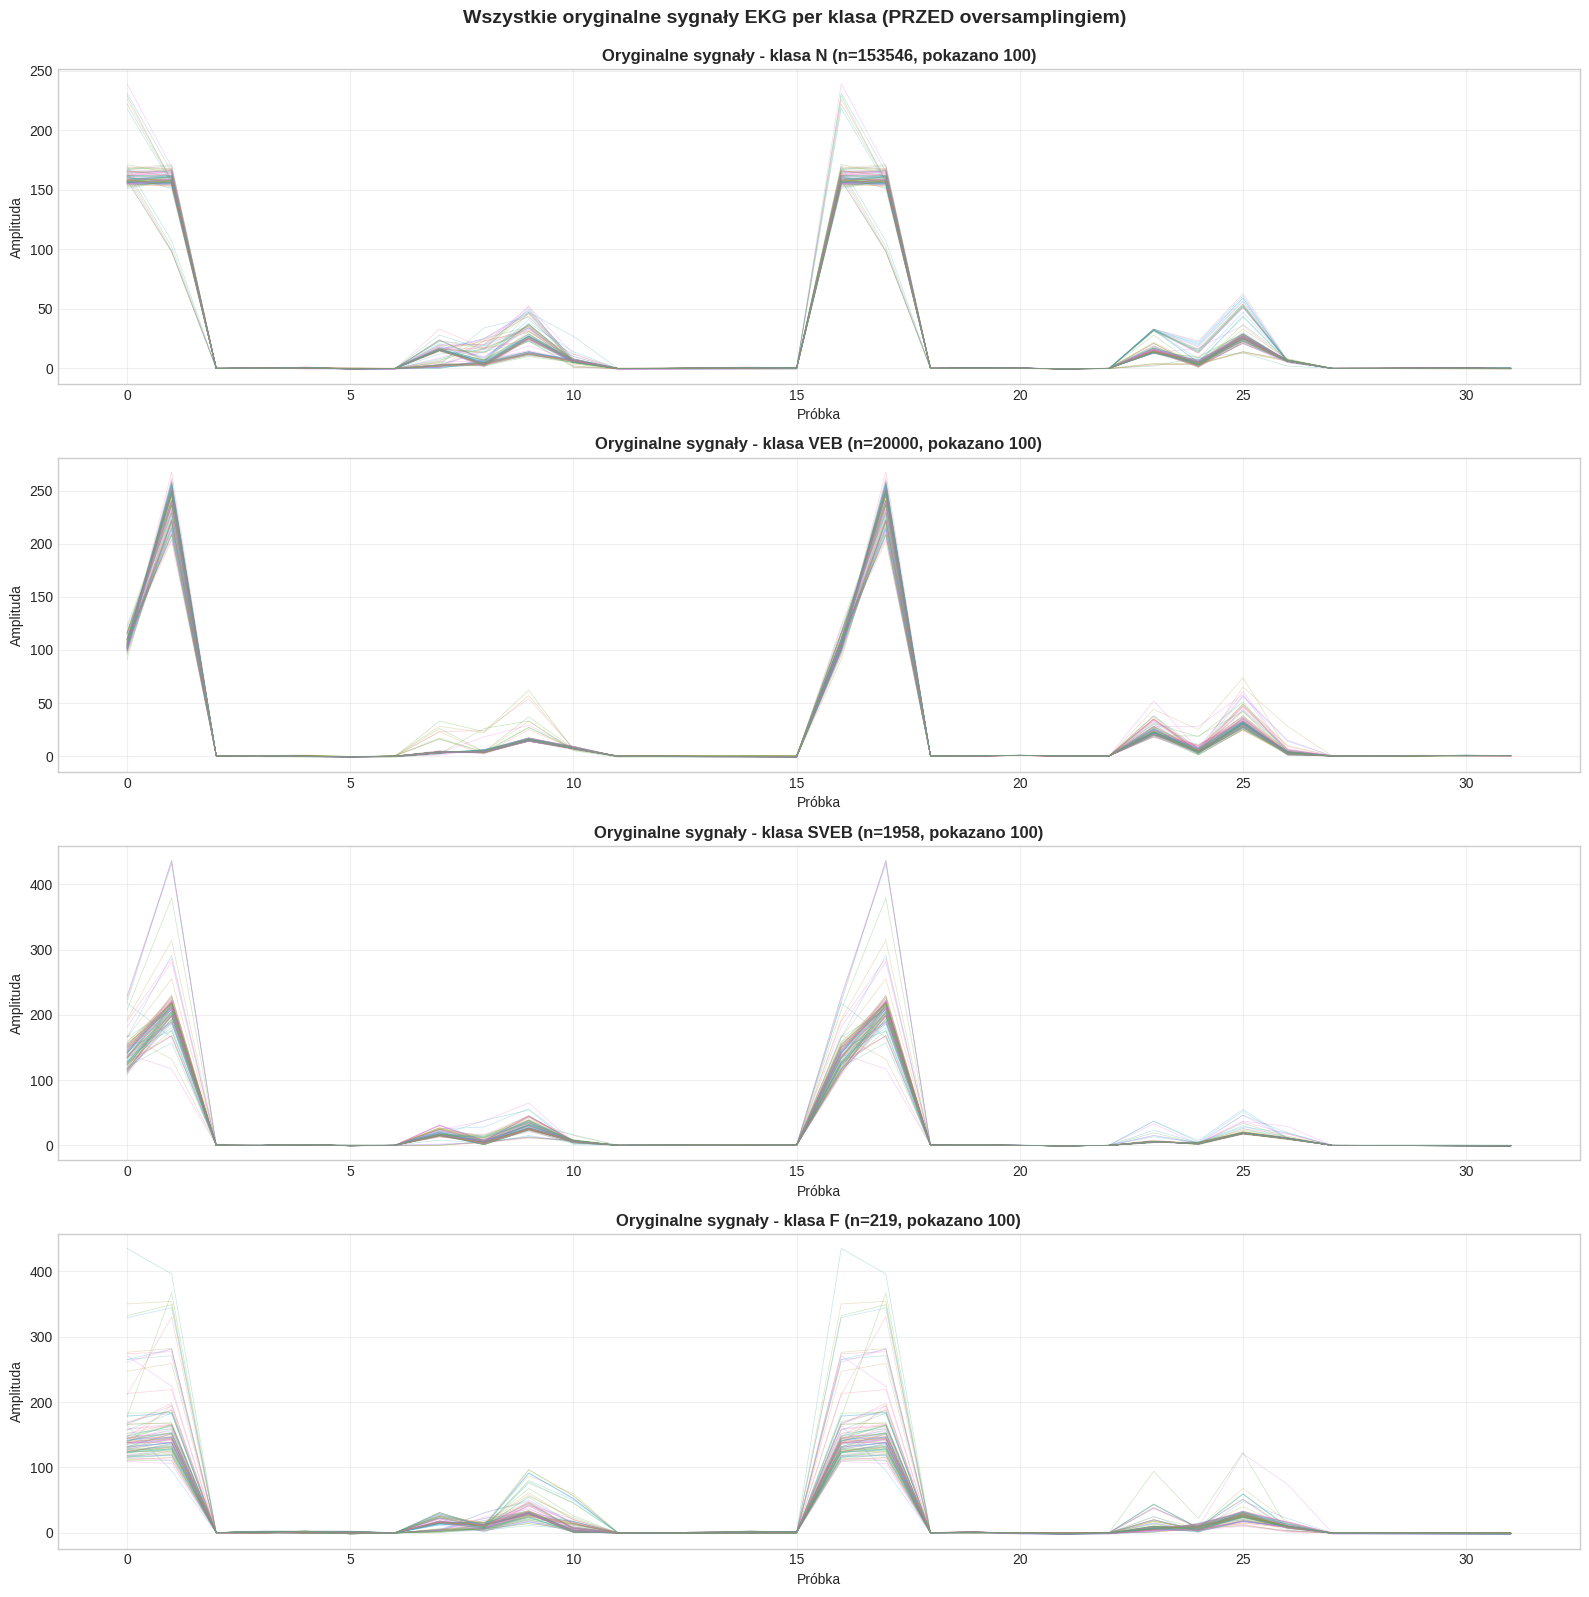

Wizualizacja oryginalna ukończona!


In [10]:
# Wizualizacja wszystkich sygnałów z każdej klasy - PRZED oversamplingiem
print("Generowanie wizualizacji oryginalnych sygnałów...")

fig, axes = plt.subplots(4, 1, figsize=(16, 16))
class_names = ['N', 'VEB', 'SVEB', 'F']

for idx, class_name in enumerate(class_names):
    # Filtruj dane dla danej klasy (przed oversamplingiem)
    class_data = df_no_q[df_no_q['type'] == class_name]
    
    # Wybierz kolumny sygnału
    signal_cols = [col for col in class_data.columns if col not in ['record', 'type']]
    
    # Limit próbek do wyświetlenia (żeby wykres był czytelny)
    max_samples = min(100, len(class_data))
    
    for i in range(max_samples):
        signal = class_data.iloc[i][signal_cols].values
        axes[idx].plot(signal, alpha=0.3, linewidth=0.5)
    
    axes[idx].set_title(f'Oryginalne sygnały - klasa {class_name} (n={len(class_data)}, pokazano {max_samples})', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Próbka')
    axes[idx].set_ylabel('Amplituda')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Wszystkie oryginalne sygnały EKG per klasa (PRZED oversamplingiem)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Wizualizacja oryginalna ukończona!")

Generowanie wizualizacji syntetycznych sygnałów SMOTE...
Oryginalne próbki treningowe per klasa: {0: 122837, 1: 16000, 2: 1566, 3: 175}
Oczekiwana liczba syntetycznych próbek per klasa: {0: 0, 1: 106837, 2: 121271, 3: 122662}

Oryginalne próbki treningowe: 140578
Syntetyczne próbki SMOTE: 350770
Faktyczny rozkład syntetycznych próbek: {3: 122662, 2: 121271, 1: 106837}

Oryginalne próbki treningowe: 140578
Syntetyczne próbki SMOTE: 350770
Faktyczny rozkład syntetycznych próbek: {3: 122662, 2: 121271, 1: 106837}


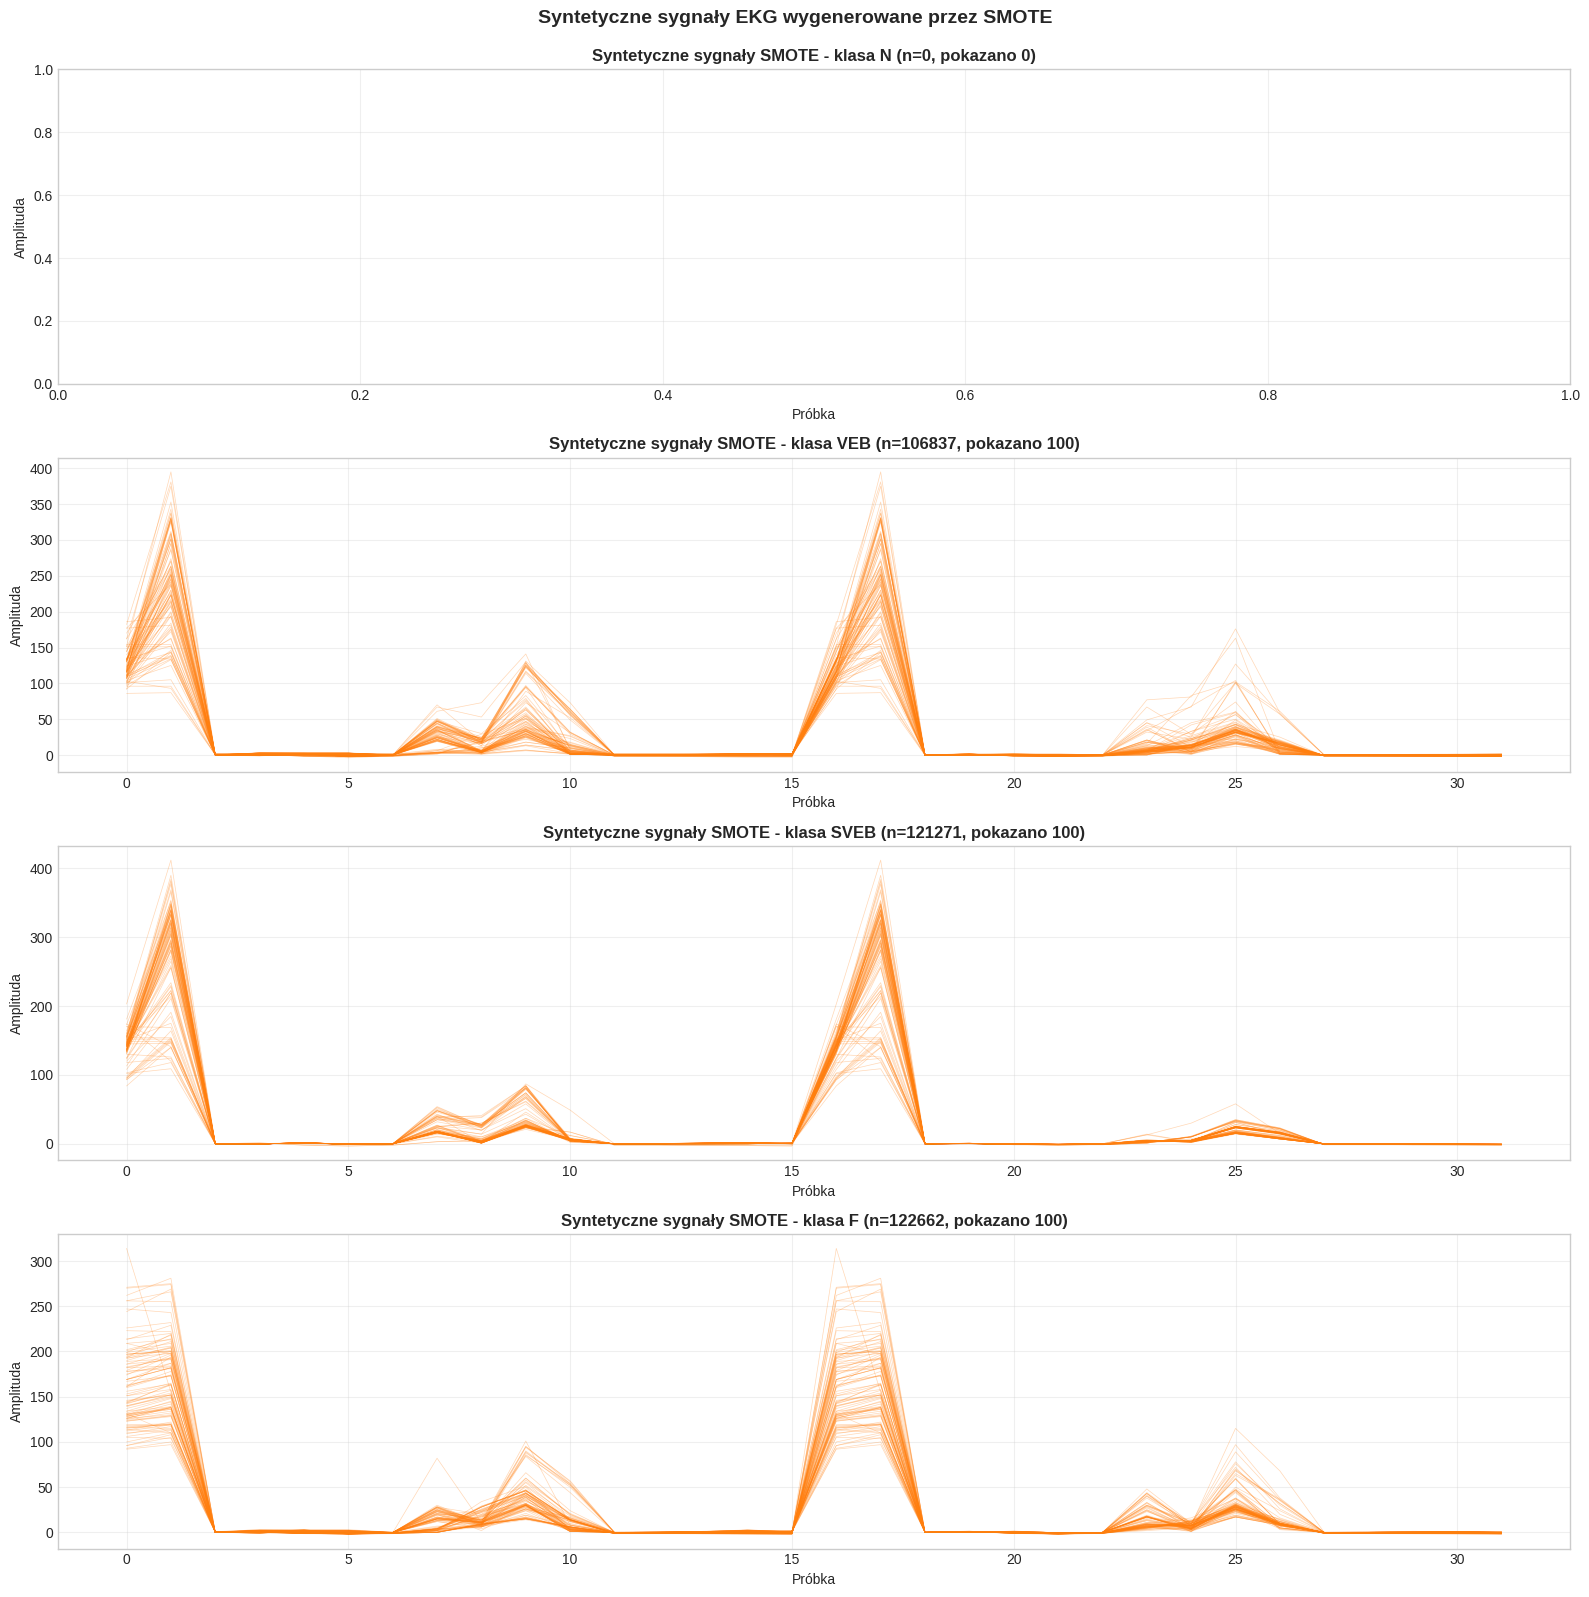

In [14]:
# Wizualizacja TYLKO syntetycznych sygnałów utworzonych przez SMOTE
print("Generowanie wizualizacji syntetycznych sygnałów SMOTE...")

import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

df_copy = df.copy()
df_copy = df_copy.drop('record', axis=1)
df_copy = df_copy.dropna()
df_copy = df_copy[df_copy["type"] != 'Q']
df_copy["type"] = df_copy["type"].map({'N': 0, 'VEB': 1, 'SVEB': 2, 'F': 3})

X = df_copy.drop('type', axis=1)
Y = df_copy['type']

X_train_orig, _, y_train_orig, _ = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

original_train_counts = y_train_orig.value_counts().to_dict()
print(f"Oryginalne próbki treningowe per klasa: {original_train_counts}")

max_class_count = max(original_train_counts.values())
synthetic_counts_expected = {k: max_class_count - v for k, v in original_train_counts.items()}
print(f"Oczekiwana liczba syntetycznych próbek per klasa: {synthetic_counts_expected}")

# Wykonaj SMOTE (wyniki będą inne niż w preproces_baseline_forest, ale STRUKTURA ta sama)
ros = SMOTE()  # bez random_state - tak jak w funkcji
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_orig, y_train_orig)

# Syntetyczne próbki są dodane NA KOŃCU przez SMOTE
n_original = len(X_train_orig)
X_synthetic = X_train_resampled.iloc[n_original:]
y_synthetic = y_train_resampled.iloc[n_original:]

print(f"\nOryginalne próbki treningowe: {n_original}")
print(f"Syntetyczne próbki SMOTE: {len(X_synthetic)}")
print(f"Faktyczny rozkład syntetycznych próbek: {y_synthetic.value_counts().to_dict()}")

fig, axes = plt.subplots(4, 1, figsize=(16, 16))
class_names = ['N', 'VEB', 'SVEB', 'F']

for idx, (class_label, class_name) in enumerate(zip([0, 1, 2, 3], class_names)):
    # Pobierz TYLKO syntetyczne próbki danej klasy
    class_mask = y_synthetic == class_label
    synthetic_class_data = X_synthetic[class_mask]
    
    n_synthetic = len(synthetic_class_data)
    
    # Limit próbek do wyświetlenia
    max_samples = min(100, n_synthetic)
    
    if n_synthetic > 0:
        for i in range(max_samples):
            signal = synthetic_class_data.iloc[i].values
            axes[idx].plot(signal, alpha=0.3, linewidth=0.5, color='tab:orange')
    
    axes[idx].set_title(f'Syntetyczne sygnały SMOTE - klasa {class_name} (n={n_synthetic}, pokazano {max_samples})', 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Próbka')
    axes[idx].set_ylabel('Amplituda')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Syntetyczne sygnały EKG wygenerowane przez SMOTE', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
# Syntetyczne próbki wyglądają bardzo podobnie (chyba to możliwe dlatego że oryginalne dane są ustandaryzowane w czasie tzn. szczyty zawsze w podobnych miejscach tak jak na wykresach wyżej)
# Można użyć w treningu sieci

# TODO -> jedna sieć na tym samym df co baseline, druga eksperymentalnie z ważonymi wagami